In [ ]:
import gzip, json, string, math
import os, sys
from pathlib import Path
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Repo root (works when opened from notebooks/)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# Hand-written features live in src/features.py (same code as below originally)
from src.features import counts, feature, TF, DF, TFIDF


# Amazon Review Rating Prediction

This notebook is your **Assignment2** workbook, kept in the same section order as `workbook.html`:

1. Dataset Description / EDA  
2. Predictive Task & Features  
3. Modeling  
4. Literature  
5. Conclusions  

Only change for this repo layout: `counts` / `feature` / `TF` / `DF` / `TFIDF` are imported from `src/features.py` (your original code).  
Rendered HTML copy: `notebooks/workbook.html`.


# 1. Dataset Description

In this assignment, we analyze the **Amazon Books Reviews** dataset (500k samples).

We load the first 500,000 reviews for analysis.

In [69]:
dataset = []

# Prefer dataset/Books.json.gz in this repo; otherwise AMAZON_BOOKS_PATH / local Archive copy
_candidates = [
    Path(os.environ["AMAZON_BOOKS_PATH"]).expanduser() if os.environ.get("AMAZON_BOOKS_PATH") else None,
    ROOT / "dataset" / "Books.json.gz",
    ROOT / "dataset" / "Books_500k.json",
    Path("/Users/suiso/Desktop/Archive/AI/CSE 158/assignment2/dataset/Books_500k.json"),
    Path("/Users/suiso/Desktop/Archive/AI/CSE 158/assignment2/dataset/Books.json.gz"),
]
DATA_PATH = next((p for p in _candidates if p is not None and p.exists()), ROOT / "dataset" / "Books.json.gz")
print("Loading from:", DATA_PATH)

if DATA_PATH.suffix == ".gz":
    f = gzip.open(DATA_PATH)
    for l in f:
        d = json.loads(l)
        dataset.append(d)
        if len(dataset) >= 500000:
            break
    f.close()
else:
    with open(DATA_PATH, encoding="utf-8") as f:
        for i, l in enumerate(f):
            if i >= 500000:
                break
            dataset.append(json.loads(l))

print("500k data completed" if len(dataset) >= 500000 else f"loaded {len(dataset)} reviews")


500k data completed


In [68]:
print(dataset[:1])

[{'overall': 5.0, 'verified': False, 'reviewTime': '08 12, 2005', 'reviewerID': 'A1C6M8LCIX4M6M', 'asin': '0001713353', 'style': {'Format:': ' Paperback'}, 'reviewerName': 'June Bug', 'reviewText': "This book is a winner with both of my boys.  They really enjoy the pictures and the story.  It's a classic.", 'summary': "Children's favorite", 'unixReviewTime': 1123804800}]


## 1.1 Rating Distribution

We first examine how ratings (1–5) are distributed.

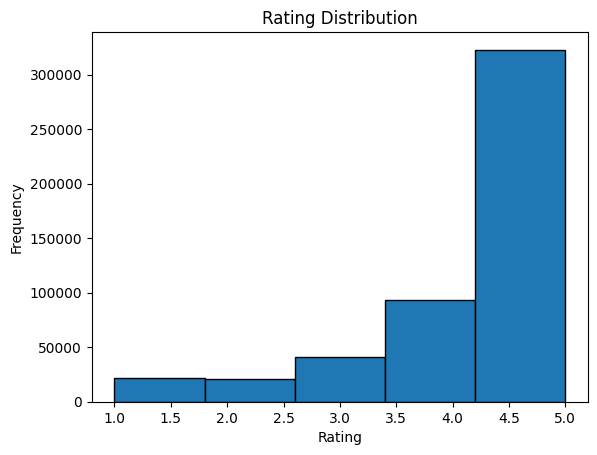

Average rating: 4.347412
Rating std: 1.0837623827463287


In [70]:
ratings = [d["overall"] for d in dataset]
plt.hist(ratings, bins=5, edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

print("Average rating:", np.mean(ratings))
print("Rating std:", np.std(ratings))

### Explanation

- The ratings are highly skewed toward 4–5 stars, showing significant class imbalance.  
- This means predicting high ratings is easy, but predicting low ratings is harder.  
- The imbalance justifies using regularization and careful evaluation (MSE).

## 1.2 Review Length Distribution

We inspect the number of words in each **reviewText**

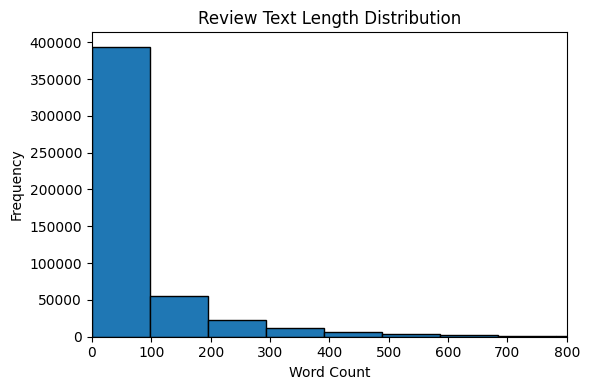

Average length: 78.25412
Median length: 32.0
95th percentile: 315.0


In [71]:
# Compute text lengths safely
review_lengths = [len(d.get("reviewText", "").split()) for d in dataset]

plt.figure(figsize=(6, 4))
plt.hist(review_lengths, bins=50, edgecolor='black')
plt.title("Review Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, 800)
plt.tight_layout()
plt.show()

print("Average length:", np.mean(review_lengths))
print("Median length:", np.median(review_lengths))
print("95th percentile:", np.percentile(review_lengths, 95))

### Explanation

- Most reviews are short (median ~32 words) with a small number of long reviews.  
- Short reviews contain limited information and increase sparsity.  
- This supports using unigram features and TF-IDF.

## 1.3 Summary Length Distribution
We analyze the size of summary text.

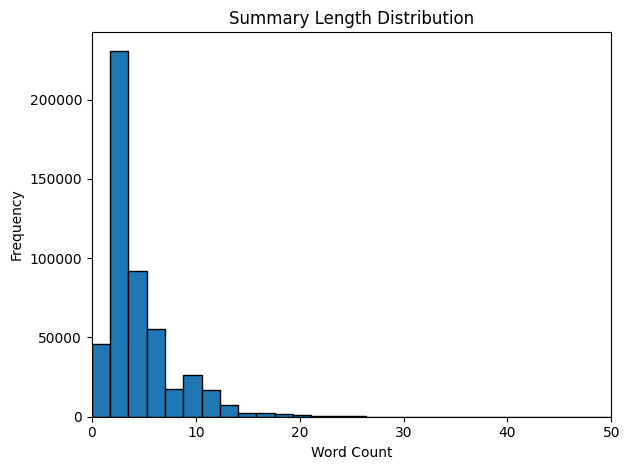

Avg summary length: 4.332706
Median summary length: 3.0
95th percentile: 11.0


In [78]:
summary_lengths = [len(d.get("summary","").split()) for d in dataset]

plt.hist(summary_lengths, bins=50, edgecolor='black')
plt.title("Summary Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

print("Avg summary length:", np.mean(summary_lengths))
print("Median summary length:", np.median(summary_lengths))
print("95th percentile:", np.percentile(summary_lengths, 95))

### Explanation
- Summaries are extremely short (median ~3 words).  
- They provide strong but brief sentiment signals and complement the full review text.  
- Their short length reduces sparsity problems.

## 1.4 Verified vs Non-Verified Distribution

We check whether reviews come from verified purchases.

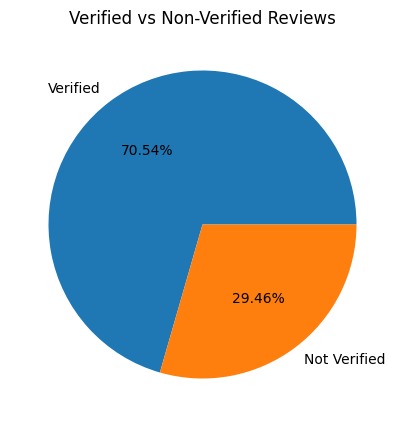

Verified ratio: 0.705372


In [77]:
verified_count = sum(1 for d in dataset if d.get("verified", False))
total = len(dataset)

plt.figure(figsize=(5,5))
plt.pie([verified_count, total - verified_count],
        labels=["Verified", "Not Verified"],
        autopct='%1.2f%%',
        colors=["#1f77b4", "#ff7f0e"],
       )
plt.title("Verified vs Non-Verified Reviews")
plt.show()

print("Verified ratio:", verified_count/total)

### Explaination
- About 70% of reviews are verified purchases, indicating mostly reliable data.  
- Non-verified reviews may contain more noise.  

## 1.5 Review Year Distribution

We examine the timestamp trend.

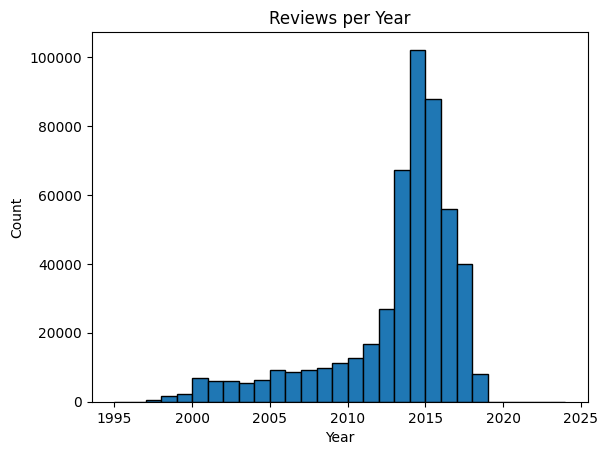

In [72]:
years = [
    datetime.datetime.fromtimestamp(d["unixReviewTime"], tz=datetime.timezone.utc).year
    for d in dataset
]

plt.hist(years, bins=range(1995,2025), edgecolor='black')
plt.title("Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### Explanation
- Most reviews come from 2014–2018, with few very old or very new reviews.  
- The dataset is stable enough for simple text models.

## 1.6 Top Unigrams / Bigrams
We compute the most common single words and two-word phrases.

In [79]:
punctuation = set(string.punctuation)
unigram_counter = Counter()
bigram_counter = Counter()

for d in dataset:
    review = d.get("reviewText", "").lower()
    summary = d.get("summary", "").lower()
    text = review + " " + summary
    
    r = ''.join([c if c not in punctuation else ' ' for c in text])
    tokens = r.split()
    unigram_counter.update(tokens)

    # update bigrams
    for i in range(len(tokens) - 1):
        bi = tokens[i] + " " + tokens[i+1]
        bigram_counter.update([bi])
    
top_unigrams = unigram_counter.most_common(30)
top_bigrams = bigram_counter.most_common(30)

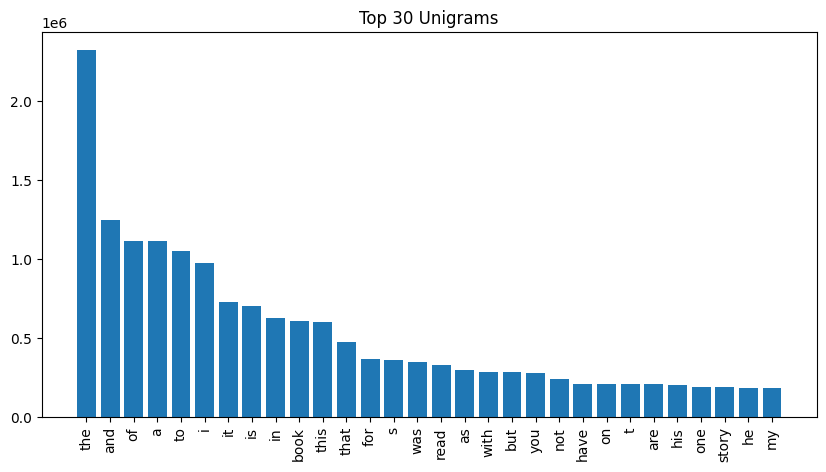

In [74]:
words, uni_counts = zip(*top_unigrams)

plt.figure(figsize=(10,5), edgecolor= "black")
plt.bar(words, uni_counts)
plt.xticks(rotation=90)
plt.title("Top 30 Unigrams")
plt.show()

### Explanation
- Most top words are common stopwords (e.g. "the", "and", "of"), which don’t carry useful meaning.
- A few domain words like "book", "read", "story" appear often but aren’t strong sentiment signals.
- Because frequent words are mostly generic, models should use TF-IDF to highlight more setimental terms.

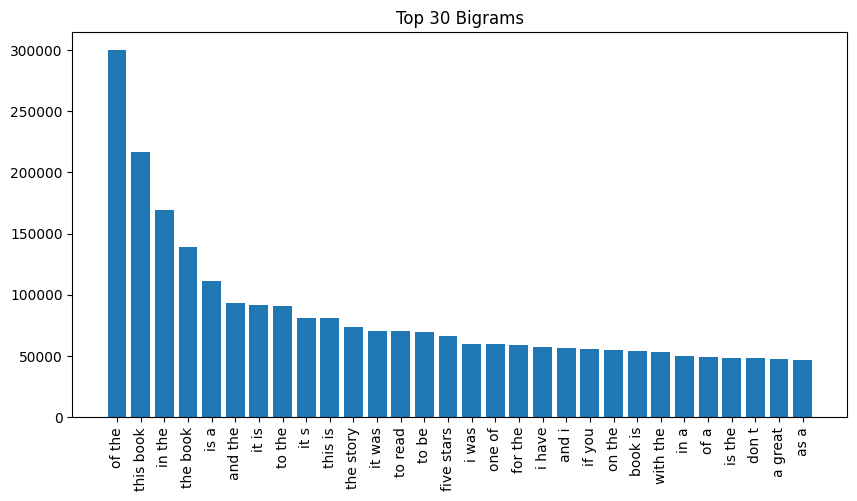

In [75]:
bi_words, bi_counts = zip(*top_bigrams)

plt.figure(figsize=(10,5), edgecolor= "black")
plt.bar(bi_words,  bi_counts)
plt.xticks(rotation=90)
plt.title("Top 30 Bigrams")
plt.show()

### Explanation
- Most frequent bigrams are structural phrases (e.g., “of the”, “this book”) rather than sentiment.  
- Informative bigrams occur rarely, making them sparse.  

### 1.7 Example Reviews (Positive / Neutral / Negative)

We display examples of different sentiment levels.

In [76]:
pos = next(d for d in dataset if d["overall"] == 5)
neu = next(d for d in dataset if d["overall"] == 3)
neg = next(d for d in dataset if d["overall"] <= 2)

print("Positive Example:\n", pos["summary"], "\n", pos["reviewText"], "\n")
print("Neutral Example:\n", neu["summary"], "\n", neu["reviewText"], "\n")
print("Negative Example:\n", neg["summary"], "\n", neg["reviewText"], "\n")

Positive Example:
 Children's favorite 
 This book is a winner with both of my boys.  They really enjoy the pictures and the story.  It's a classic. 

Neutral Example:
 Outdated, but a good 1960s primer 
 41 years later:

The cheese is government cheese.

The mice objected to the king's idea of good manners as species-centric, and rebelled.

The king blamed the peasants, and forbade them to keep cats or chase mice from their homes.

This made things worse. Peasants that could afford to do so moved as far away from mice as possible.

I can't wait for the next chapter. 

Negative Example:
 Two Stars 
 Looking for a Louis Untermeyer book  from the 1980s and this was not the one, 



### Explanation
- Positive reviews contain strong sentiment words, neutral reviews are descriptive, and negative reviews express complaints.  
- This shows that sentiment-bearing unigrams are useful predictors for rating.  
- The examples validate the effectiveness of text-based features.

## 1.8 Key Insights from EDA

#### 1. Class imbalance:
Most reviews are 5 stars -> models may overpredict high stars

#### 2. Review text is short:
Median 32 words → limited information for low rating reviews.

#### 3. Verified reviews dominate:
Adds reliability; potentially useful metadata.

#### 4. Temporal concentration:
Most reviews from 2014–2018.

#### 5. High-frequency neutral words dominate:
`"book"`, `"read"`, `"story"`, `"the"` appear extremely often → motivates TF-IDF instead of raw counts.

# 2. Predictive Task & Features

## 2.1 Task Definition
The goal is to **predict the star rating (1-5)** of an Amazon book review **using only its text**.

We treat this as a **regression problem** and evaluate all models with **Mean Squared Error (MSE)**

## 2.2 Preprocessing
We apply minimal preprocessing to preserve as much raw text information as possible:
- Convert text to lowercase
- Remove punctuation
- Combine `reviewText + summary`
- Split into tokens using whitespace

This ensures consistent input for unigram/bigram extraction and TF-IDF vectorization.

Preprocessing is implemented inside the feature functions.

## 2.3 Feature Engineering

### (a) Count-Based Features: Unigrams, Bigrams, and Both

We extract:
- **Unigrams** — single words  
- **Bigrams** — adjacent pairs (e.g. `"very good"`, `"not good"`)  
- **Both** — union of unigrams + bigrams

We count their frequencies over the entire dataset and select **top 1000** of each type.

In [ ]:
import inspect
# Same `counts` implementation as in Assignment2 / workbook.html
print(inspect.getsource(counts))


def counts(dataset):
    """
    Compute the most frequent unigrams, bigrams, and combined features in the dataset.
    Returns:
        topUnigrams, topBigrams, topBoth
    """
    punctuation = set(string.punctuation)
    
    # Count unigrams and bigrams
    unigramCount = defaultdict(int) # {word_set1 -> count1, ...}
    bigramCount = defaultdict(int)
    
    # 1. Counts for unigrams and bigrams
    for d in dataset:
        # safely extract
        review = d.get("reviewText", "").lower()
        summary = d.get("summary", "").lower()
    
        # combine before cleaning
        text = review + " " + summary
    
        # remove punctuation
        r = ''.join([c if c not in punctuation else ' ' for c in text])
    
        # split all tokens
        ws = r.split()

        
        # Count unigrams
        for w in ws:
            unigramCount[w] += 1

        # Count bigrams
        for i in range(len(ws) - 1):
            bg = ws[i] + " " + ws[i+1]
            bigramCount[b

In [ ]:
import inspect
# Same `feature` implementation as in Assignment2 / workbook.html
print(inspect.getsource(feature))


def feature(datum, wordId, wordSet, which):
    """
    Build a feature vector (count-based) for a single review.
    The vector includes:
        - unigram counts
        - bigram counts
        - offset term (bias)
    """
    
    feat = [0] * len(wordSet)
    punctuation = set(string.punctuation)

    review = datum.get("reviewText", "").lower()
    summary = datum.get("summary", "").lower()
    
    text = review + " " + summary

    r = ''.join([c if c not in punctuation else ' ' for c in text])
    
    ws = r.split()

    if which in ("unigrams", "both"):
        for w in ws:
            if w in wordId:
                feat[wordId[w]] += 1

    if which in ("bigrams", "both"):
        for i in range(len(ws) - 1):
            bg = ws[i] + " " + ws[i+1]
            if bg in wordId:
                feat[wordId[bg]] += 1

    feat.append(1)  # offset
    return feat


### (b) Binary Term Frequency (TF)

For each review, `TF` gives a **binary indicator** of word presence:
- `TF[w] = 1` -> word appears
- `TF[w] = 0` -> word does not appear

In [ ]:
import inspect
# Same `TF` implementation as in Assignment2 / workbook.html
print(inspect.getsource(TF))


def TF(query, wordSet, which):
    """
    Term Frequency: Binary indicator if word is present
    which: "unigrams", "bigrams", or "both"
    """
    tf = defaultdict(int)
    punctuation = set(string.punctuation)
    
    review = query.get("reviewText", "").lower()
    summary = query.get("summary", "").lower()
    text = review + " " + summary
    r = ''.join([c if c not in punctuation else ' ' for c in text])
    ws = r.split()
    
    # Unigrams
    if which in ("unigrams", "both"):
        for w in ws:
            if w in wordSet:
                tf[w] = 1
    
    # Bigrams
    if which in ("bigrams", "both"):
        for i in range(len(ws) - 1):
            bg = ws[i] + " " + ws[i+1]
            if bg in wordSet:
                tf[bg] = 1
    
    return tf


### (c) Document Frequency (DF)
DF measures how many reviews contain a given word:

- Common words → high DF → less informative  
- Rare words → lower DF → more informative  

DF is required for computing IDF.

In [ ]:
import inspect
# Same `DF` implementation as in Assignment2 / workbook.html
print(inspect.getsource(DF))


def DF(dataset, wordSet, which):
    """
    Document Frequency: How many documents contain each word
    which: "unigrams", "bigrams", or "both"
    """
    df = defaultdict(int)
    
    for d in dataset:
        review = d.get("reviewText", "").lower()
        summary = d.get("summary", "").lower()
        text = review + " " + summary
        r = ''.join([c if c not in string.punctuation else ' ' for c in text])
        ws = r.split()
        
        seen = set()  # each vocab only count once in one review
        
        # Unigrams
        if which in ("unigrams", "both"):
            for w in ws:
                if w in wordSet and w not in seen:
                    df[w] += 1
                    seen.add(w)
        
        # Bigrams
        if which in ("bigrams", "both"):
            for i in range(len(ws) - 1):
                bg = ws[i] + " " + ws[i+1]
                if bg in wordSet and bg not in seen:
                    df[bg] += 1
                    seen.add(bg)
    

### (d) TF-IDF Representation

TF-IDF improves on raw counts by combining:

- **TF** — does the word appear in the review?  
- **IDF** — how rare is the word across all reviews?

This weighting:

- down-weights `"the"`, `"and"`  
- up-weights sentiment words like `"excellent"`, `"terrible"`  
- produces strong performance in linear models

In [ ]:
import inspect
# Same `TFIDF` implementation as in Assignment2 / workbook.html
print(inspect.getsource(TFIDF))


def TFIDF(query, df, dataset, wordSet, which):
    """
    Compute TF-IDF vector for a single document
    """
    tf = TF(query, wordSet, which)  # 传入 which
    N = len(dataset)
    
    tfidfQuery = [
        tf[w] * math.log2(N / df[w]) if df[w] > 0 else 0
        for w in wordSet
    ]
    return tfidfQuery


# 3. Modeling

This section evaluates several models for predicting review ratings, comparing different text feature representations (Counts vs TF-IDF, Unigrams vs Bigrams vs Both Combined) and different learning models (Ridge, Lasso, Random Forest).

All models are evaluated using **Mean Squared Error (MSE)** on a fixed 80/20 train–test split.

In [63]:
train_data, test_data = dataset[:400000], dataset[400000:]

### Extract Top 1000 Features for Each Representation

We now run `counts()` on the *training set only* to obtain:

- `uni`  → top 1000 unigrams  
- `bi`   → top 1000 bigrams  
- `both` → top 1000 combined features  

These will be used to build the feature vectors for all models.

In [65]:
# Extract top unigrams, bigrams, and combined vocab
uni, bi, both = counts(train_data)

print("Top unigram count:", len(uni))
print("Top bigram count:", len(bi))
print("Top both count:   ", len(both))

Top unigram count: 1000
Top bigram count: 1000
Top both count:    1000


## 3.1 Baseline: Predict Mean Rating

### Motivation: 
The baseline model predictss the mean train-set rating for every review.

This provides a simple performance lower bound - any useful model should outperform this baseline.

In [47]:
# Baseline: always predict the mean rating
mean_rating = np.mean([d["overall"] for d in train_data])
baseline_mse = np.mean((mean_rating - np.array([d["overall"] for d in test_data]))**2)
print("Baseline MSE (predict mean):", baseline_mse)

Baseline MSE (predict mean): 1.0166298288562499


### Interpretation:

The baseline model predicts the mean rating for all reviews.

All subsequent models aim to reduce this error by using textual features.

## 3.2 Ridge Regression with Counts (Unigrams / Bigrams / Both)

### Motivation:
Ridge Regression is well suited for text data because the L2 penalty reduces overfitting in high-dimensional sparse feature spaces.

##### We test three feature types:
- Unigrams: individual words
- Bigrams: word pairs
- Both: combined vocabulary


In [26]:
def fitModel(wList, which, train_data, test_data):
    wordId = dict(zip(wList, range(len(wList))))
    wordSet = set(wList)
    
    # Build train set
    X_train, y_train = [], []
    for d in train_data:
        feat = feature(d, wordId, wordSet, which)
        X_train.append(feat)
        y_train.append(d["overall"])
    
    # Build test set
    X_test, y_test = [], []
    for d in test_data:
        feat = feature(d, wordId, wordSet, which)
        X_test.append(feat)
        y_test.append(d["overall"])
    
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    clf = Ridge(alpha=1)
    clf.fit(X_train, y_train)
    theta = clf.coef_
    
    
    # Evaluate on TEST set
    predictions = clf.predict(X_test)
    mse = np.mean((predictions - y_test)**2)
    
    return clf, theta, predictions, mse

In [27]:
ridge_mse = list()

for which, wList in ("unigrams", uni), ("bigrams", bi), ("both", both):
    clf, theta, predictions, mse = fitModel(wList, which, train_data, test_data)
    ridge_mse.append(mse)
    print(which + " MSE = " + str(mse))

unigrams MSE = 0.6331964473919817
bigrams MSE = 0.7143848012232792
both MSE = 0.63631823545387


### Interpretation:
Unigram counts outperform bigrams because bigrams are very sparse and appear inconsistently acorss reviews.

Using both unigrams and bigrams increases dimensionality but does not improve accuracy.

## 3.3 Ridge Regression with TF-IDF

##### TF-IDF vectors generated from unigrams, bigrams, or a combination of both

### Motivation:
TF-IDF downweights extremely common words and highlights informative, sentiment-bearing words.

We expect TF-IDF to outperform raw counts.

In [29]:
def fitModel_TFIDF(wordSet, which, train_data, test_data):
    """
    which: "unigrams", "bigrams", or "both"
    """
    # 1. Build document frequency from TRAINING data only
    df = DF(train_data, wordSet, which)
    
    # 2. Build training set
    X_train, y_train = [], []
    for d in train_data:
        tfidf_d = TFIDF(d, df, train_data, wordSet, which)
        X_train.append(tfidf_d)
        y_train.append(d["overall"])
    
    # 3. Build test set
    X_test, y_test = [], []
    for d in test_data:
        tfidf_d = TFIDF(d, df, train_data, wordSet, which)
        X_test.append(tfidf_d)
        y_test.append(d["overall"])
    
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    # 4. Fit ridge regression
    clf = Ridge(alpha=1)
    clf.fit(X_train, y_train)

    theta = clf.coef_
    # 5. Evaluate on TEST set
    predictions = clf.predict(X_test)
    mse = np.mean((predictions - y_test) ** 2)
    
    return clf, theta, predictions, mse

In [36]:
ridge_tfidf_mse = list()

for which, wList in ("unigrams", uni), ("bigrams", bi), ("both", both):
    wordSet = set(wList)
    clf, theta, predictions, mse = fitModel_TFIDF(wordSet, which, train_data, test_data)
    ridge_tfidf_mse.append(mse)
    print(which + " TFIDF MSE = " + str(mse))

unigrams TFIDF MSE = 0.5895929220639794
bigrams TFIDF MSE = 0.7008856728796117
both TFIDF MSE = 0.6007546081258593


### Interpretation:
TF-IDF substantially improves performance for all N-gram types.

**TF-IDF Unigrams** achieve the lowest MSE among all Ridge models, showing that weighting words matters more than including bigrams.

## 3.4 Lasso Regression with TF-IDF

##### TF-IDF vectors generated from unigrams, bigrams, or a combination of both

### Motivation:
Lasso performs feature selection by shrinking many coefficients to zero.

This helps identify the most important sentiment words.

In [28]:
def fitModel_Lasso(wordSet, which, train_data, test_data):
    df = DF(train_data, wordSet, which)
    
    X_train, y_train = [], []
    for d in train_data:
        X_train.append(TFIDF(d, df, train_data, wordSet, which))
        y_train.append(d["overall"])
    
    X_test, y_test = [], []
    for d in test_data:
        X_test.append(TFIDF(d, df, train_data, wordSet, which))
        y_test.append(d["overall"])
    
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    clf = Lasso(alpha=0.001, max_iter=2000)
    clf.fit(X_train, y_train)
    
    predictions = clf.predict(X_test)
    mse = np.mean((predictions - y_test) ** 2)
    
    return clf, clf.coef_, predictions, mse

In [37]:
lasso_mse = list()

for which, wList in ("unigrams", uni), ("bigrams", bi), ("both", both):
    wordSet = set(wList)
    _, _, _, mse = fitModel_Lasso(wordSet, which, train_data, test_data)
    lasso_mse.append(mse)
    print(which + " TDIDF Lasso MSE = " + str(mse))

unigrams TDIDF Lasso MSE = 0.5896525142176081
bigrams TDIDF Lasso MSE = 0.7005462644099902
both TDIDF Lasso MSE = 0.6016770817726425


### Interpretation:

Lasso performs slightly worse than Ridge because it removes many correlated features, but it produces sparse coefficients that are useful for feature analysis.

## 3.5 Random Forest with TF-IDF (Unigrams)

### Motivation:
Random Forest provides a non-linear baseline for comparison

In [33]:
def fitModel_RF(wordSet, which, train_data, test_data):
    df = DF(train_data, wordSet, which)
    
    X_train, y_train = [], []
    for d in train_data:
        X_train.append(TFIDF(d, df, train_data, wordSet, which))
        y_train.append(d["overall"])
    
    X_test, y_test = [], []
    for d in test_data:
        X_test.append(TFIDF(d, df, train_data, wordSet, which))
        y_test.append(d["overall"])
    
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    clf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)
    
    predictions = clf.predict(X_test)
    mse = np.mean((predictions - y_test) ** 2)
    
    return clf, None, predictions, mse

In [34]:
wordSet = set(uni)
clf_rf, _, pred_rf, mse_rf = fitModel_RF(wordSet, "unigrams", train_data, test_data)
print("Random Forest MSE:", mse_rf)

Random Forest MSE: 0.6991355241758725


### Interpretation:
Random Forest improves over the baseline but underperforms linear models.

This is expected because TF-IDF vectors are too sparse for decision trees to split on effectively.

## 3.6 Result Summary

In [50]:
results = pd.DataFrame({
    'Model': ['Baseline (Mean)', 
              'Ridge + Count Unigrams', 'Ridge + Count Bigrams', 'Ridge + Count Both',
              'Ridge + TFIDF Unigrams', 'Ridge + TFIDF Bigrams', 'Ridge + TFIDF Both',
              'Lasso + TFIDF Unigrams', 'Lasso + TFIDF Bigrams', 'Lasso + TFIDF Both',
              'Random Forest + TFIDF Unigrams'],
    'MSE': [baseline_mse, 
            ridge_mse[0], ridge_mse[1], ridge_mse[2],
            ridge_tfidf_mse[0], ridge_tfidf_mse[1], ridge_tfidf_mse[2],
            lasso_mse[0], lasso_mse[1], lasso_mse[2],
            mse_rf]
})

results['Improvement vs Baseline'] = ((baseline_mse - results['MSE']) / baseline_mse * 100).round(2).astype(str) + '%'
results

,Model,MSE,Improvement vs Baseline
0,Baseline (Mean),1.016630,0.0%
1,Ridge + Count Unigrams,0.633196,37.72%
2,Ridge + Count Bigrams,0.714385,29.73%
3,Ridge + Count Both,0.636318,37.41%
4,Ridge + TFIDF Unigrams,0.589593,42.01%
5,Ridge + TFIDF Bigrams,0.700886,31.06%
6,Ridge + TFIDF Both,0.600755,40.91%
7,Lasso + TFIDF Unigrams,0.589653,42.0%
8,Lasso + TFIDF Bigrams,0.700546,31.09%
9,Lasso + TFIDF Both,0.601677,40.82%


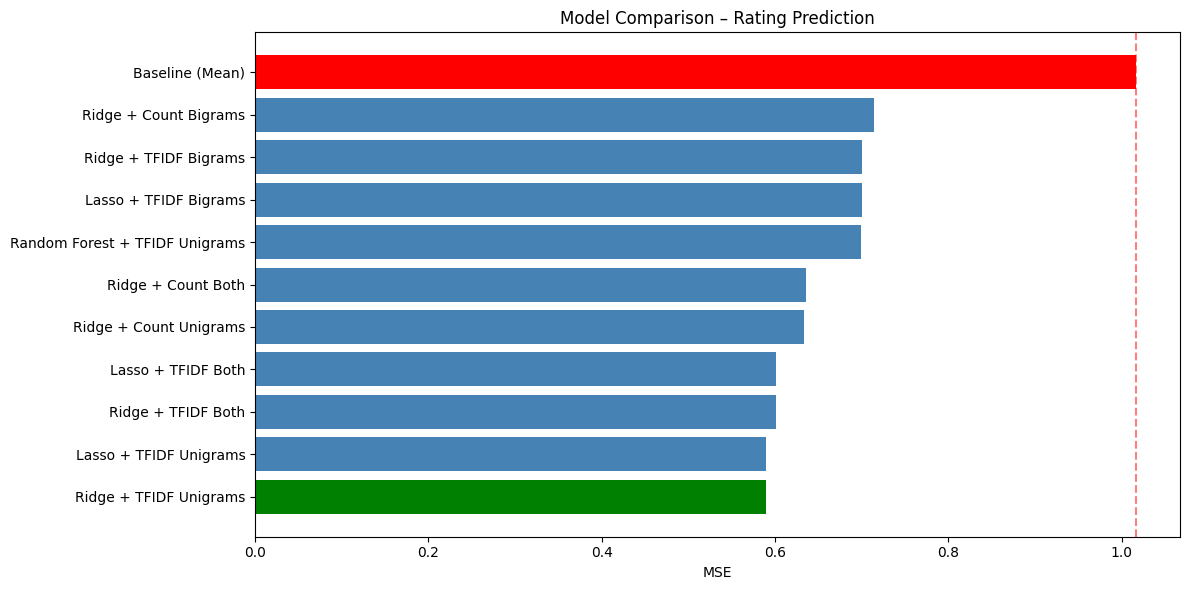

In [49]:
plt.figure(figsize=(12, 6))

# 1. Sort by MSE
df_sorted = results.sort_values("MSE", ascending=True)

# 2. Assign colors
colors = []
for model, mse in zip(df_sorted["Model"], df_sorted["MSE"]):
    if mse == df_sorted["MSE"].min():
        colors.append("green") # lowest MSE (best)
    elif "Baseline" in model:
        colors.append("red") # baseline
    else:
        colors.append("steelblue") # normal models

# 3. Plot bar chart
plt.barh(df_sorted["Model"], df_sorted["MSE"], color=colors)
plt.xlabel("MSE")
plt.title("Model Comparison – Rating Prediction")

# 4. Baseline horizontal line
plt.axvline(
    x=baseline_mse, 
    color="red", 
    linestyle="--", 
    alpha=0.5,
)

plt.tight_layout()
plt.show()

### Key Findings:
- **TF-IDF > Count features**
- **Unigrams > Bigrams** due to sparsity
- **Ridge Regression** consistently performs best among tested models
- The best configuration is **Ridge + TF-IDF Unigrams**, improving MSE by ~42%

## 3.7 Feature Analysis: Most Predictive Words

### Motivation:
To understand what the best model learned, we inspect the largest positive and negative coefficients of **Ridge + TF-IDF Unigrams**.

In [53]:
# Get the best model (Ridge + TFIDF Unigrams)
wordSet = set(uni)
clf, theta, predictions, mse = fitModel_TFIDF(wordSet, "unigrams", train_data, test_data)

# Map coefficients to words
word_list = list(wordSet)
coef_pairs = list(zip(word_list, theta))

# Sort by coefficient value (ascending: most negative first -> most positive last)
coef_pairs_sorted = sorted(coef_pairs, key=lambda x: x[1])

# Words predicting LOW ratings (most negative coefficients)
print("Top 10 words predicting LOW ratings:")
for word, coef in coef_pairs_sorted[:10]:        # First 10 = most negative
    print(f"  {word}: {coef:.4f}")

# Words predicting HIGH ratings (most positive coefficients)
print("\nTop 10 words predicting HIGH ratings:")
for word, coef in coef_pairs_sorted[-10:][::-1]:  # Last 10, reversed to show highest first
    print(f"  {word}: {coef:.4f}")

Top 10 words predicting LOW ratings:
  not: -0.1619
  waste: -0.1614
  star: -0.1462
  arp: -0.1397
  disappointing: -0.1265
  boring: -0.1252
  worst: -0.1119
  stars: -0.1098
  the: -0.0838
  terrible: -0.0820

Top 10 words predicting HIGH ratings:
  five: 0.2654
  rvw: 0.1561
  great: 0.1266
  excellent: 0.0753
  love: 0.0680
  best: 0.0677
  read: 0.0644
  loved: 0.0619
  amazing: 0.0608
  awesome: 0.0585


### Interpretation:
Negative coefficients correspond to strongly negative sentiment words ("waste, disappointing", "boring"),

while positive coeffieicnts reflect strong positivity ("great", "excellent", "love").

This confirms that the model is capturing sentiment effectively.

## 3.8 Discussion

**Why Ridge Regression works well:**
- Text data is high-dimensional and sparse (thousands of features, most are zero)
- L2 regularization prevents overfitting by shrinking coefficients
- Linear models can effectively capture sentiment signals in word frequencies

**Why TF-IDF outperforms raw counts:**
- TF-IDF down-weights common words (e.g., "the", "and") that appear everywhere
- Emphasizes words that are distinctive to specific reviews
- Better captures sentiment-bearing terms

**Why Random Forest underperforms:**
- Tree-based models struggle with sparse, high-dimensional data
- Decision trees make axis-aligned splits, which are inefficient when features are sparse
- Would need extremely deep trees to capture word importance

**Why unigrams beat bigrams:**
- Bigrams create much larger, sparser feature space
- Many bigrams appear only once, providing little predictive value
- Unigrams capture sentiment words effectively (e.g., "great", "terrible")

# 4. Literature
##### There is extensive research on predicting product ratings from review text and user behavior:

- Pang & Lee (2002) showed that bag-of-words and n-gram features work well for sentiment and rating prediction from text.
- McAuley & Leskovec (2013) found that Amazon review text provides strong signals for predicting product ratings, directly matching our task.
- Salton (1975) introduced TF-IDF, which down-weights very common neutral words—consistent with our results that TF-IDF outperforms count features.

### References

Pang, B., & Lee, L. (2002). Thumbs up? Sentiment classification using machine learning techniques.

McAuley, J., & Leskovec, J. (2013). Hidden factors and hidden topics: Understanding rating dimensions with review text.

Salton, G. (1975). A Vector Space Model for Automatic Indexing.

# 5. Conclusions

Overall, the best-performing model is **`Unigrams + TF-IDF with Ridge Regression`**, achieving an MSE of **0.590** and a **42% improvement over the baseline**. This shows that using word frequencies (TF-IDF) with a simple linear model (Ridge Regression) works very well for predicting book ratings.

## 5.1 Key Findings
- Unigrams outperform bigrams due to sparsity.
- TF-IDF improves predictive power compared to raw counts.
- Ridge Regression handles large sparse feature spaces well.
- Random Forest underperforms on sparse, high-dimensional text data.

## 5.2 Limitations
1. **Class imbalance**:

   Dataset is highly skewed toward 5-star reviews, biasing models toward predicting high ratings.
   
2. **Short reviews**:

   Extremely short reviews ("good", "ok", etc.) contain minimal information and introduce noise.

3. **Bigram sparsity**:

   Many bigrams appear infrequently, leading to high variance and reduced performance.

## 5.3 Future Improvements
#### 1. **Handle Class Imbalance**

The majority of reviews are 5 stars, causing the model to over-predict high ratings.

Future work could explore:

- Oversampling 1–2 star reviews
- Undersampling majority classes

This could reduce prediction bias for low-rating reviews.


#### 2. **Enhance Text Representation**

TF-IDF relies only on word frequency and lacks semantic understanding.

Future directions:

- Word2Vec or GloVe embeddings

  Capture semantic similarity (e.g. “great” ≈ “excellent”).
  
- Using review summaries separately

  Summaries may condense sentiment that complements review text.

#### 3. **Add Metadata Features**

Non-text attributes may correlate strongly with ratings but were not used here.

Potential useful signals:

- Verified purchase status
- Review Length
- Review time / year

Metadata often captures reliability and context (e.g. longer reviews may reflect stronger sentiment).

## 5.4 Summary

Ridge Regression with TF-IDF Unigrams provides a simple yet powerful approach for rating prediction.
Although effective, the model’s performance could be improved by addressing dataset imbalance, incorporating semantic embeddings, and enriching input features with metadata.